# GoPay Google Play Review - Data Preprocessing

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `03 - Preprocessing`

This notebook continues from the review scraping process covered in [2-Gopay-Review-EDA.ipynb](https://colab.research.google.com/drive/1ISGrXpD_I_7GDQQrEpuJN9NpGXTNxeCw?usp=sharing)

---

## Objective

This notebook transforms the raw GoPay review data (from notebook 02 — EDA) into a clean, analysis-ready dataset for sentiment analysis and TF-IDF extraction.

## Preprocessing Pipeline

The preprocessing steps are ordered intentionally — each step depends on the output of the previous one:

| Step | Task | Rationale |
|------|------|-----------|
| 1 | Drop unnecessary columns | Remove metadata not needed for NLP |
| 2 | Handle missing & empty values | Ensure every row has usable text |
| 3 | Remove duplicates | Avoid bias from repeated reviews |
| 4 | Sentiment labeling | Map scores → Positive / Neutral / Negative |
| 5 | Case folding (lowercasing) | Normalize text before any pattern matching |
| 6 | Text cleaning (URLs, emojis, punctuation, numbers) | Remove noise **before** tokenization so tokens are clean |
| 7 | Indonesian slang normalization | Convert informal abbreviations to standard words |
| 8 | Tokenization | Split cleaned text into word tokens |
| 9 | Stopword removal (Indonesian) | Remove common words that don't carry sentiment |
| 10 | Stemming (Indonesian — Sastrawi) | Reduce words to root form |
| 11 | Reconstruct cleaned text | Join tokens back into a single string for TF-IDF |
| 12 | Post-preprocessing validation & comparison | Verify quality and compare before vs after |

## 1. Setup & Installation

In [1]:
!pip install Sastrawi -q
!pip install emoji -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

In [7]:
df = pd.read_csv('gopay_reviews_raw.csv')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 367195 entries, 0 to 367194
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   reviewId              367195 non-null  str  
 1   userName              367195 non-null  str  
 2   userImage             367195 non-null  str  
 3   content               367194 non-null  str  
 4   score                 367195 non-null  int64
 5   thumbsUpCount         367195 non-null  int64
 6   reviewCreatedVersion  306103 non-null  str  
 7   at                    367195 non-null  str  
 8   replyContent          61660 non-null   str  
 9   repliedAt             61660 non-null   str  
 10  appVersion            306103 non-null  str  
dtypes: int64(2), str(9)
memory usage: 135.5 MB


## 3. Drop Unnecessary Columns

For sentiment analysis on review text, we only need the review content, its score, and the timestamp. Columns like `userName`, `userImage`, and `reviewId` are metadata that don't contribute to NLP tasks.

In [10]:
# Columns to keep for sentiment analysis
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']

df = df.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining columns: {df.columns.tolist()}')
df.head(3)

Dropped 4 columns: ['reviewId', 'userName', 'userImage', 'appVersion']
Remaining columns: ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54
1,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN
2,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN


## 4. Handle Missing & Empty Values

In [11]:
# Check missing values before cleaning
print('Missing values before cleaning:')
df.isnull().sum()

Missing values before cleaning:


content                      1
score                        0
thumbsUpCount                0
reviewCreatedVersion     61092
at                           0
replyContent            305535
repliedAt               305535
dtype: int64

In [12]:
rows_before = len(df)

# Drop rows where 'content' is null or empty/whitespace
df = df.dropna(subset=['content'])
df = df[df['content'].str.strip() != '']

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} rows with missing/empty content')
print(f'Remaining: {rows_after:,} rows')

Removed 1 rows with missing/empty content
Remaining: 367,194 rows


## 5. Remove Duplicate Reviews

Duplicate review text can bias word frequencies and model training. We keep the first occurrence and remove subsequent duplicates.

In [13]:
rows_before = len(df)

df = df.drop_duplicates(subset=['content'], keep='first')

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} duplicate reviews')
print(f'Remaining: {rows_after:,} unique reviews')

Removed 148,550 duplicate reviews
Remaining: 218,644 unique reviews


## 6. Convert Data Types

In [14]:
df['at'] = pd.to_datetime(df['at'])
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

df.dtypes

content                            str
score                            int64
thumbsUpCount                    int64
reviewCreatedVersion               str
at                      datetime64[us]
replyContent                       str
repliedAt               datetime64[us]
dtype: object

## 7. Sentiment Labeling

We create a sentiment label based on the review score. This labeled column will serve as the target variable for sentiment classification.

| Score | Sentiment |
|-------|-----------|
| 1 - 2 | Negative |
| 3     | Neutral  |
| 4 - 5 | Positive |

In [15]:
def assign_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(assign_sentiment)

df['sentiment'].value_counts()

sentiment
positive    149295
negative     59804
neutral       9545
Name: count, dtype: int64

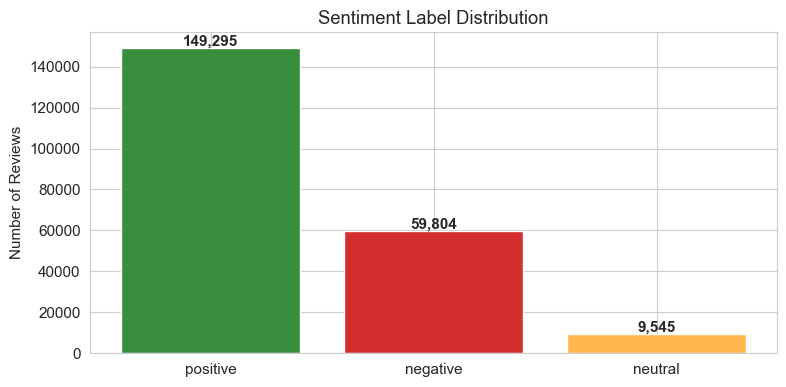


Class proportions:


sentiment
positive    68.28
negative    27.35
neutral      4.37
Name: proportion, dtype: float64

In [16]:
# Visualize sentiment distribution
colors_sent = {'positive': '#388e3c', 'neutral': '#ffb74d', 'negative': '#d32f2f'}

fig, ax = plt.subplots(figsize=(8, 4))
sent_counts = df['sentiment'].value_counts()
ax.bar(sent_counts.index, sent_counts.values,
       color=[colors_sent[s] for s in sent_counts.index], edgecolor='white')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Label Distribution')
for i, (s, c) in enumerate(sent_counts.items()):
    ax.text(i, c + len(df)*0.005, f'{c:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClass proportions:')
(df['sentiment'].value_counts(normalize=True) * 100).round(2)

## 8. Text Preprocessing

This is the core NLP pipeline. Each step is applied sequentially. We store intermediate results in a new column `cleaned_content` to preserve the original `content` column for reference.

> **Important note on language:** GoPay reviews are in **Indonesian (Bahasa Indonesia)**. This means we must use:
> - **Sastrawi** for Indonesian stemming (not Porter/Snowball which are English)
> - **Indonesian stopwords** from Sastrawi (not NLTK's English stopwords)
> - **Indonesian slang dictionary** for normalization (not English contractions)

### 8.1 Case Folding (Lowercasing)

Convert all text to lowercase so that "Bagus", "BAGUS", and "bagus" are treated as the same word. This must happen **before** tokenization and stopword matching.

In [17]:
df['cleaned_content'] = df['content'].astype(str).str.lower()

# Show before vs after
df[['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,"Baru kali ini pakai gopay kek gini, tadi saya ...","baru kali ini pakai gopay kek gini, tadi saya ..."
1,busuk,busuk
2,selalu dapat bonus,selalu dapat bonus
3,"good, kasih donk promonya","good, kasih donk promonya"
4,terbaik mendukung bwnget,terbaik mendukung bwnget


### 8.2 Text Cleaning

Remove noise elements that don't contribute to sentiment meaning. This is done **before tokenization** so that URLs and special characters don't produce garbage tokens.

What we remove:
- URLs (http/https links)
- Email addresses
- Emojis
- Numbers/digits
- Punctuation & special characters
- Extra whitespace

In [18]:
def clean_text(text):
    """Remove non-textual noise from a review string."""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove digits/numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['cleaned_content'] = df['cleaned_content'].apply(clean_text)

# Show before vs after
df[['content', 'cleaned_content']].sample(5, random_state=42)

,content,cleaned_content
6146,kita sangat puas,kita sangat puas
169599,Aplikasi masih belum sempurna ketika ganti Hp ...,aplikasi masih belum sempurna ketika ganti hp ...
109914,tapi saldoku sisa 1 boleh nambah gak,tapi saldoku sisa boleh nambah gak
367056,Pulsa nya ternyata lebih murah yaa!!,pulsa nya ternyata lebih murah yaa
331589,Lancar gak ribet,lancar gak ribet


### 8.3 Indonesian Slang Normalization

Indonesian informal text is full of abbreviations and slang (e.g., "gak" → "tidak", "bgt" → "banget", "emg" → "memang"). Normalizing these ensures the stemmer can process them correctly and that semantically identical words are unified.

We use a manually curated slang dictionary common in Indonesian app reviews.

In [19]:
# Indonesian slang dictionary — common abbreviations found in app reviews
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'g': 'tidak', 'tdk': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'kagak': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk', 'u': 'untuk',
    'yg': 'yang', 'yng': 'yang',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'dengan',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah', 'uda': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'lg': 'lagi', 'lgi': 'lagi',
    'bs': 'bisa', 'bsa': 'bisa',
    'klo': 'kalau', 'kl': 'kalau', 'klu': 'kalau', 'kalo': 'kalau',
    'jg': 'juga', 'jga': 'juga',
    'aja': 'saja', 'aj': 'saja',
    'dr': 'dari',
    'krn': 'karena', 'karna': 'karena', 'krna': 'karena',
    'bgt': 'banget', 'bngt': 'banget', 'bngtt': 'banget',
    'bgtt': 'banget', 'bangett': 'banget', 'bener': 'benar',
    'emg': 'memang', 'emang': 'memang',
    'hrs': 'harus',
    'jd': 'jadi', 'jdi': 'jadi',
    'dpt': 'dapat',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'skg': 'sekarang',
    'trs': 'terus', 'trus': 'terus',
    'org': 'orang', 'ornag': 'orang',
    'msh': 'masih',
    'sy': 'saya', 'aku': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'w': 'saya',
    'lo': 'kamu', 'lu': 'kamu',
    'gmn': 'bagaimana', 'gimana': 'bagaimana',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'bnr': 'benar',
    'bkn': 'bukan',
    'dmn': 'dimana', 'dmna': 'dimana',
    'gpp': 'tidak apa apa', 'gapapa': 'tidak apa apa',
    'makasih': 'terima kasih', 'makasi': 'terima kasih', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'tq': 'terima kasih',
    'mantap': 'bagus', 'mantab': 'bagus', 'mantapp': 'bagus',
    'top': 'bagus', 'josss': 'bagus', 'jos': 'bagus', 'keren': 'bagus',
    'jelek': 'buruk', 'parah': 'buruk', 'ancur': 'buruk', 'sampah': 'buruk',
    'apk': 'aplikasi', 'app': 'aplikasi',
    'hp': 'handphone',
    'banget': 'sekali',
    'bner': 'benar',
    'ngk': 'tidak', 'engga': 'tidak', 'enggak': 'tidak',
    'dlu': 'dulu', 'dl': 'dulu',
    'pke': 'pakai', 'pake': 'pakai', 'pk': 'pakai',
    'smpe': 'sampai', 'smpai': 'sampai', 'sampe': 'sampai',
    'ntar': 'nanti', 'tar': 'nanti',
    'kmrn': 'kemarin', 'kmarin': 'kemarin',
}

print(f'Slang dictionary size: {len(slang_dict)} entries')

Slang dictionary size: 115 entries


In [20]:
def normalize_slang(text):
    """Replace Indonesian slang words with their standard form."""
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)


df['cleaned_content'] = df['cleaned_content'].apply(normalize_slang)

# Show examples where slang was normalized
changed_mask = df['content'].astype(str).str.lower() != df['cleaned_content']
df[changed_mask][['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",baru kali ini pakai gopay kek gini tadi saya b...
3,"good, kasih donk promonya",good kasih donk promonya
5,token nya murah2,token nya murah
6,kalau emang udah tidak ada niat pengadaan top ...,kalau memang sudah tidak ada niat pengadaan ba...
7,GOPAY SOK AKRAB SAMSUNG JELEK,gopay sok akrab samsung buruk


### 8.4 Tokenization

Split the cleaned text into individual word tokens. At this point the text is already lowercase, cleaned, and slang-normalized — so the tokens produced will be high quality.

In [21]:
df['tokens'] = df['cleaned_content'].apply(word_tokenize)

df[['cleaned_content', 'tokens']].head(5)

,cleaned_content,tokens
0,baru kali ini pakai gopay kek gini tadi saya b...,"[baru, kali, ini, pakai, gopay, kek, gini, tad..."
1,busuk,[busuk]
2,selalu dapat bonus,"[selalu, dapat, bonus]"
3,good kasih donk promonya,"[good, kasih, donk, promonya]"
4,terbaik mendukung bwnget,"[terbaik, mendukung, bwnget]"


In [22]:
# Token count stats
df['token_count'] = df['tokens'].apply(len)

print(f'Token count statistics:')
df['token_count'].describe().round(1)

Token count statistics:


count    218644.0
mean         10.6
std          11.7
min           0.0
25%           4.0
50%           6.0
75%          13.0
max         100.0
Name: token_count, dtype: float64

### 8.5 Stopword Removal (Indonesian)

Stopwords are high-frequency words that carry little semantic meaning (e.g., "yang", "dan", "di", "ke"). We use Sastrawi's built-in Indonesian stopword list and extend it with additional domain-specific stopwords found during EDA.

In [23]:
# Load Sastrawi's Indonesian stopwords
stop_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stop_factory.get_stop_words())

# Add custom domain-specific stopwords
custom_stopwords = {
    'gopay', 'gojek', 'aplikasi', 'handphone',
    'nya', 'aja', 'sih', 'dong', 'deh', 'loh', 'nih', 'lah', 'kan', 'kok',
    'ya', 'yah', 'oh', 'ah', 'eh', 'wah',
    'tuh', 'tau', 'mau', 'mulu', 'nih', 'gitu', 'gini',
}

all_stopwords = indonesian_stopwords.union(custom_stopwords)

print(f'Sastrawi stopwords  : {len(indonesian_stopwords)}')
print(f'Custom stopwords    : {len(custom_stopwords)}')
print(f'Total stopwords     : {len(all_stopwords)}')
print(f'\nSample stopwords: {sorted(list(all_stopwords))[:20]}')

Sastrawi stopwords  : 123
Custom stopwords    : 26
Total stopwords     : 147

Sample stopwords: ['ada', 'adalah', 'agak', 'agar', 'ah', 'aja', 'akan', 'amat', 'anda', 'antara', 'anu', 'apakah', 'apalagi', 'aplikasi', 'atau', 'bagaimanapun', 'bagi', 'bahwa', 'begitu', 'belum']


In [24]:
def remove_stopwords(tokens):
    """Remove Indonesian stopwords from token list."""
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]


df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_sw']].head(5)

,tokens,tokens_no_sw
0,"[baru, kali, ini, pakai, gopay, kek, gini, tad...","[baru, kali, pakai, kek, tadi, bagus, up, lewa..."
1,[busuk],[busuk]
2,"[selalu, dapat, bonus]","[selalu, bonus]"
3,"[good, kasih, donk, promonya]","[good, kasih, donk, promonya]"
4,"[terbaik, mendukung, bwnget]","[terbaik, mendukung, bwnget]"


In [25]:
# Stopword removal impact
total_before = df['tokens'].apply(len).sum()
total_after = df['tokens_no_sw'].apply(len).sum()
total_removed = total_before - total_after

print(f'Total tokens before stopword removal : {total_before:,}')
print(f'Total tokens after stopword removal  : {total_after:,}')
print(f'Tokens removed                       : {total_removed:,} ({total_removed/total_before*100:.1f}%)')

Total tokens before stopword removal : 2,324,725
Total tokens after stopword removal  : 1,511,864
Tokens removed                       : 812,861 (35.0%)


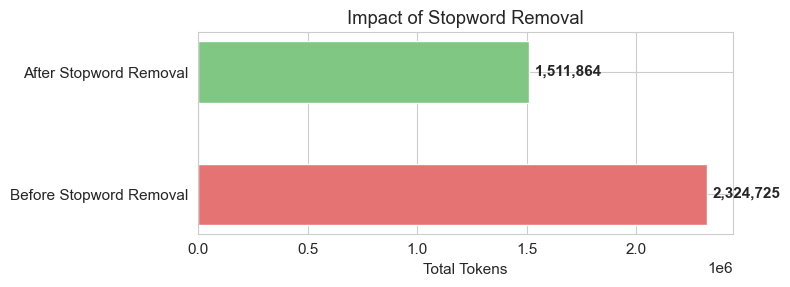

In [26]:
# Visualize stopword removal impact
fig, ax = plt.subplots(figsize=(8, 3))

categories = ['Before Stopword Removal', 'After Stopword Removal']
values = [total_before, total_after]
bar_colors = ['#e57373', '#81c784']

bars = ax.barh(categories, values, color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + total_before*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold')

ax.set_xlabel('Total Tokens')
ax.set_title('Impact of Stopword Removal')
plt.tight_layout()
plt.show()

### 8.6 Stemming (Sastrawi — Indonesian)

Stemming reduces words to their root/base form. For Indonesian, we use **Sastrawi** which understands Indonesian morphology (prefixes like *me-*, *ber-*, *pe-*, suffixes like *-kan*, *-an*, *-i*).

> **Why stemming and NOT lemmatization?**
> - The Relive notebook applied **both** lemmatization and stemming — this is redundant since they serve the same purpose (word normalization). Applying both can actually degrade results.
> - For Indonesian, Sastrawi's stemmer is more appropriate than NLTK's WordNet lemmatizer (which is designed for English).
> - We pick **one** method: Sastrawi stemming.

⚠️ **Note:** Sastrawi stemming on 300K+ reviews takes time (~10-20 minutes). Be patient.

In [28]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from joblib import Parallel, delayed

# Inisialisasi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens):
    # Setiap worker perlu instance stemmer sendiri
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    return [stemmer.stem(token) for token in tokens]

# Parallelkan di semua CPU core
df['tokens_stemmed'] = Parallel(n_jobs=-1)(
    delayed(stem_tokens)(tokens) for tokens in df['tokens_no_sw']
)

In [29]:
# Show stemming examples
print('Stemming examples:')
sample_words = ['pembayaran', 'melakukan', 'penggunaan', 'membantu', 'mengirim', 'perbaikan', 'mengecewakan', 'bermasalah']
for word in sample_words:
    print(f'  {word:20s} → {stemmer.stem(word)}')

Stemming examples:
  pembayaran           → bayar
  melakukan            → laku
  penggunaan           → guna
  membantu             → bantu
  mengirim             → kirim
  perbaikan            → baik
  mengecewakan         → kecewa
  bermasalah           → masalah


### 8.7 Reconstruct Cleaned Text

After all token-level processing, we join the tokens back into a single string. This `final_text` column will be used for TF-IDF and sentiment analysis.

In [30]:
df['final_text'] = df['tokens_stemmed'].apply(lambda tokens: ' '.join(tokens))

df[['content', 'final_text']].head(10)

,content,final_text
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",baru kali pakai kek tadi bagus up lewat brimo ...
1,busuk,busuk
2,selalu dapat bonus,selalu bonus
3,"good, kasih donk promonya",good kasih donk promonya
4,terbaik mendukung bwnget,baik dukung bwnget
5,token nya murah2,token murah
6,kalau emang udah tidak ada niat pengadaan top ...,kalau memang niat ada bagus up etoll mending u...
7,GOPAY SOK AKRAB SAMSUNG JELEK,sok akrab samsung buruk
8,e wallet multifungsi👍 saya kasih bintang 5,wallet multifungsi kasih bintang
9,terimakasih atas bantuan nya,terimakasih atas bantu


In [31]:
# Remove rows where final_text is empty after all preprocessing
rows_before = len(df)
df = df[df['final_text'].str.strip() != '']
rows_after = len(df)

print(f'Removed {rows_before - rows_after:,} rows with empty text after preprocessing')
print(f'Final dataset size: {rows_after:,} reviews')

Removed 1,709 rows with empty text after preprocessing
Final dataset size: 216,935 reviews


## 9. Post-Preprocessing Validation

We now compare the data before and after preprocessing to verify the pipeline worked correctly and to understand its impact.

In [32]:
# 9.1 — Side-by-side comparison: Original vs Final
comparison = df[['content', 'final_text', 'score', 'sentiment']].sample(10, random_state=42)
comparison

,content,final_text,score,sentiment
313830,Kesalahan dalam pengiriman semoga uang saya bi...,salah kirim moga uang,3,neutral
170151,OTP udh bener tapi masih salah emang apk baby,otp benar salah memang baby,1,negative
132596,GACORR 🔥🔥,gacorr,5,positive
349090,Gratis biaya transfer bikin kita lebih hemat👍,gratis biaya transfer bikin lebih hemat,5,positive
170832,Goodluck,goodluck,5,positive
286010,Tingkatkan teruss peforma aplikasi nya🌹,tingkat teruss forma,5,positive
126135,"kode promo jm 5 sore scam,cuma muter meter doa...",kode promo jm sore scamcuma muter meter doang ...,1,negative
145362,kenapa kalau saya mau login gopay ada bacaan O...,kalau login baca perlu baru cepat proses,1,negative
280743,Saya ada masalah dengan gopay saya dari jam 18...,masalah jam isi saldo nyata sekarang masuk,5,positive
116104,sangat membantu dlm bertransaksi.masalah finan...,sangat bantu dlm bertransaksimasalah finansial...,4,positive


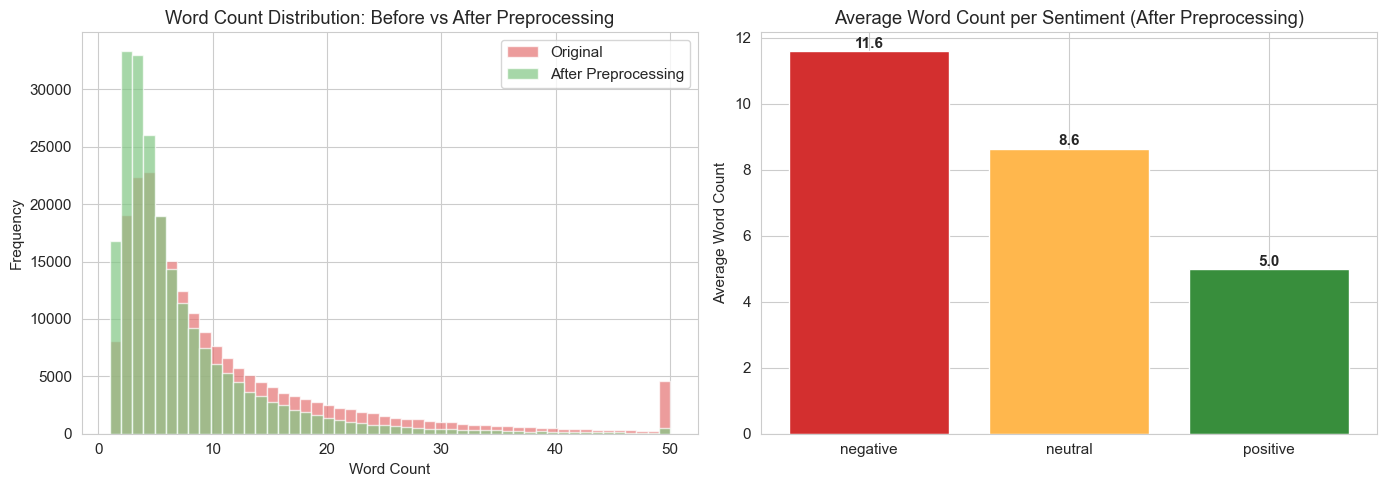

In [33]:
# 9.2 — Word count comparison: before vs after
df['original_word_count'] = df['content'].astype(str).str.split().str.len()
df['final_word_count'] = df['final_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['original_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#e57373', label='Original')
axes[0].hist(df['final_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#81c784', label='After Preprocessing')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution: Before vs After Preprocessing')
axes[0].legend()

# Average word count by sentiment
sent_order = ['negative', 'neutral', 'positive']
avg_wc = df.groupby('sentiment')['final_word_count'].mean().reindex(sent_order)
bar_colors = [colors_sent[s] for s in sent_order]
axes[1].bar(sent_order, avg_wc.values, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Average Word Count')
axes[1].set_title('Average Word Count per Sentiment (After Preprocessing)')
for i, v in enumerate(avg_wc.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

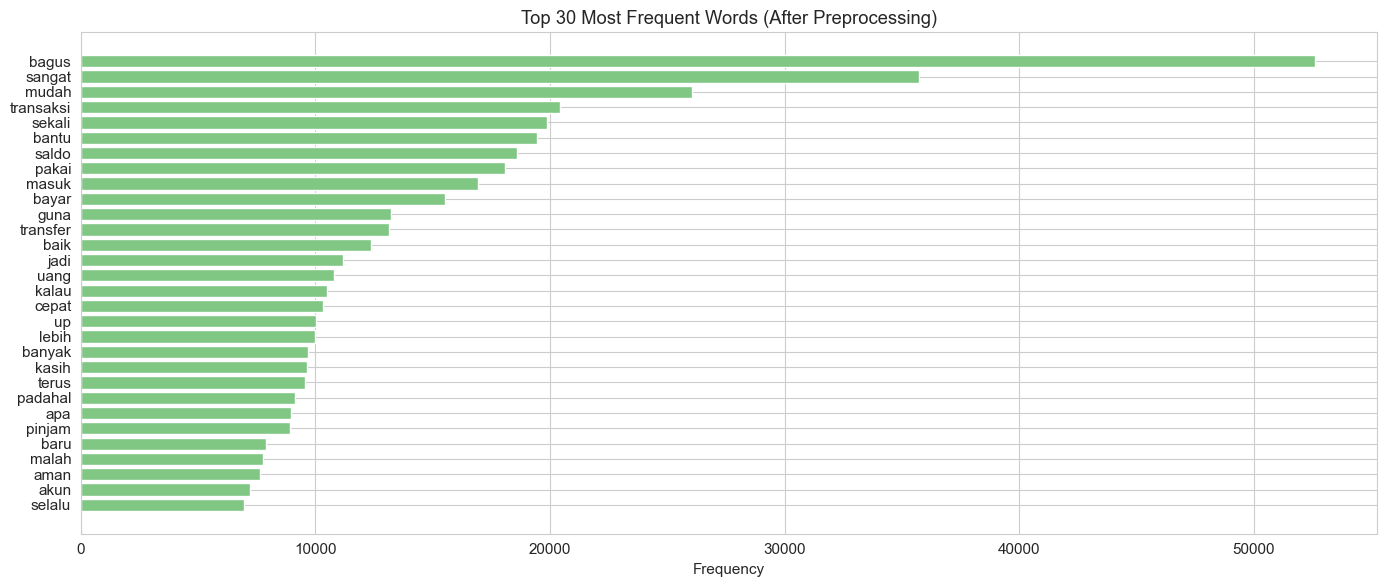

In [34]:
# 9.3 — Top words AFTER preprocessing (compare with EDA's raw word frequency)
all_final_words = ' '.join(df['final_text']).split()
final_word_freq = Counter(all_final_words)

top_30_final = final_word_freq.most_common(30)
words_f, counts_f = zip(*top_30_final)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(len(words_f)), counts_f, color='#81c784', edgecolor='white')
ax.set_yticks(range(len(words_f)))
ax.set_yticklabels(words_f)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words (After Preprocessing)')
plt.tight_layout()
plt.show()

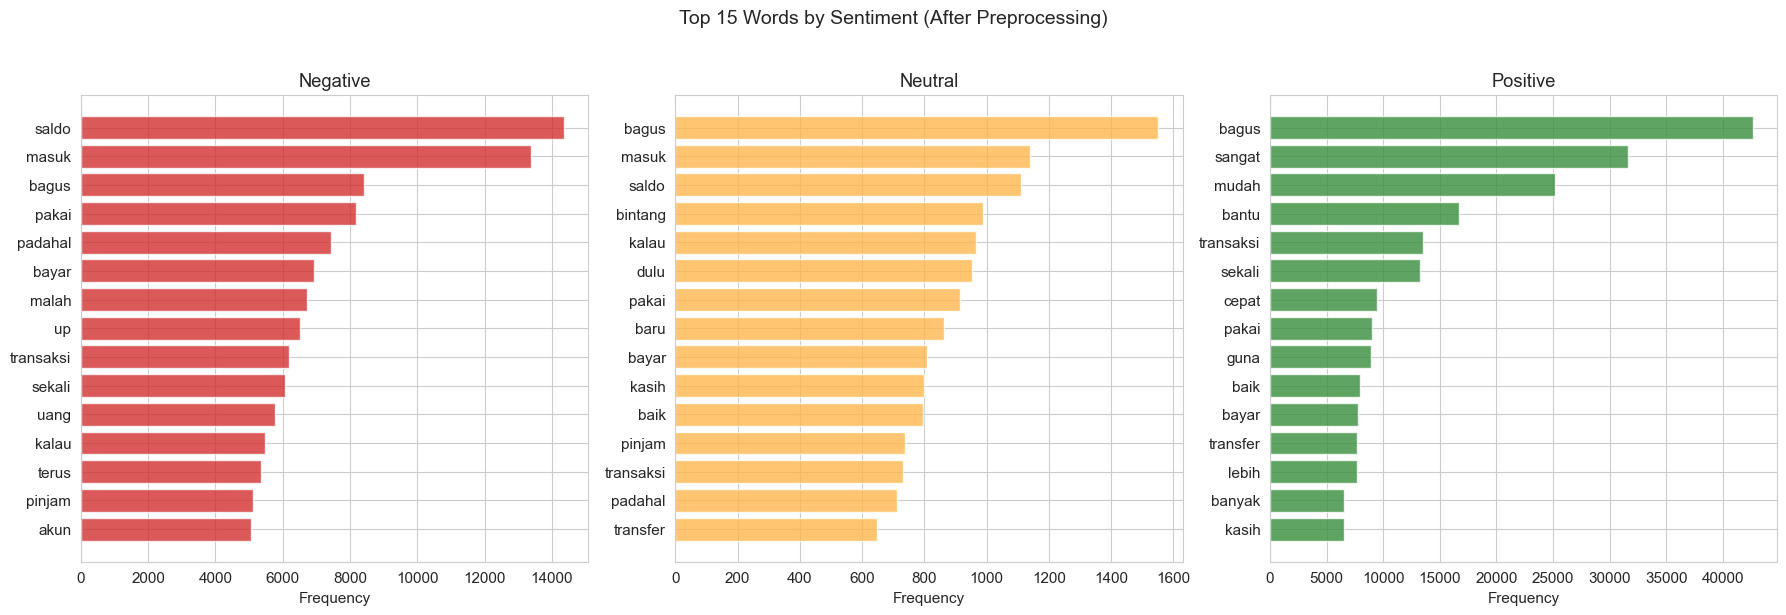

In [35]:
# 9.4 — Top words by sentiment group (after preprocessing)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sent_groups = {
    'Negative': df[df['sentiment'] == 'negative'],
    'Neutral': df[df['sentiment'] == 'neutral'],
    'Positive': df[df['sentiment'] == 'positive']
}
group_colors = ['#d32f2f', '#ffb74d', '#388e3c']

for ax, (label, grp_df), color in zip(axes, sent_groups.items(), group_colors):
    grp_words = Counter(' '.join(grp_df['final_text']).split()).most_common(15)
    w, c = zip(*grp_words)
    ax.barh(range(len(w)), c, color=color, alpha=0.8)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(f'{label}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words by Sentiment (After Preprocessing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Final Data Overview & Column Selection

In [36]:
# 10.1 — Final dataframe overview
df.info()

<class 'pandas.DataFrame'>
Index: 216935 entries, 0 to 367194
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   content               216935 non-null  str           
 1   score                 216935 non-null  int64         
 2   thumbsUpCount         216935 non-null  int64         
 3   reviewCreatedVersion  177066 non-null  str           
 4   at                    216935 non-null  datetime64[us]
 5   replyContent          59626 non-null   str           
 6   repliedAt             59626 non-null   datetime64[us]
 7   sentiment             216935 non-null  str           
 8   cleaned_content       216935 non-null  str           
 9   tokens                216935 non-null  object        
 10  token_count           216935 non-null  int64         
 11  tokens_no_sw          216935 non-null  object        
 12  tokens_stemmed        216935 non-null  object        
 13  final_text     

In [37]:
df.head(5)

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sentiment,cleaned_content,tokens,token_count,tokens_no_sw,tokens_stemmed,final_text,original_word_count,final_word_count
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54,negative,baru kali ini pakai gopay kek gini tadi saya b...,"[baru, kali, ini, pakai, gopay, kek, gini, tad...",41,"[baru, kali, pakai, kek, tadi, bagus, up, lewa...","[baru, kali, pakai, kek, tadi, bagus, up, lewa...",baru kali pakai kek tadi bagus up lewat brimo ...,41,23
1,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaT,negative,busuk,[busuk],1,[busuk],[busuk],busuk,1,1
2,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaT,positive,selalu dapat bonus,"[selalu, dapat, bonus]",3,"[selalu, bonus]","[selalu, bonus]",selalu bonus,3,2
3,"good, kasih donk promonya",5,0,2.3.0,2026-02-28 15:10:00,NaN,NaT,positive,good kasih donk promonya,"[good, kasih, donk, promonya]",4,"[good, kasih, donk, promonya]","[good, kasih, donk, promonya]",good kasih donk promonya,4,4
4,terbaik mendukung bwnget,5,0,2.0.3,2026-02-28 15:08:01,NaN,NaT,positive,terbaik mendukung bwnget,"[terbaik, mendukung, bwnget]",3,"[terbaik, mendukung, bwnget]","[baik, dukung, bwnget]",baik dukung bwnget,3,3


In [38]:
# 10.2 — Select and save only the columns needed for sentiment analysis
cols_to_save = ['content', 'score', 'at', 'thumbsUpCount', 'replyContent',
                'sentiment', 'final_text', 'tokens_stemmed']

df_clean = df[cols_to_save].copy()

print(f'Columns selected for export: {cols_to_save}')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head(5)

Columns selected for export: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_stemmed']
Final shape: 216,935 rows × 8 columns


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_stemmed
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,2026-02-28 15:16:28,0,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",negative,baru kali pakai kek tadi bagus up lewat brimo ...,"[baru, kali, pakai, kek, tadi, bagus, up, lewa..."
1,busuk,1,2026-02-28 15:14:08,0,NaN,negative,busuk,[busuk]
2,selalu dapat bonus,5,2026-02-28 15:12:17,0,NaN,positive,selalu bonus,"[selalu, bonus]"
3,"good, kasih donk promonya",5,2026-02-28 15:10:00,0,NaN,positive,good kasih donk promonya,"[good, kasih, donk, promonya]"
4,terbaik mendukung bwnget,5,2026-02-28 15:08:01,0,NaN,positive,baik dukung bwnget,"[baik, dukung, bwnget]"


## 11. Preprocessing Summary

| Metric | Value |
|--------|-------|
| Original rows | (fill in) |
| Rows after removing missing/empty | (fill in) |
| Rows after removing duplicates | (fill in) |
| Final rows after preprocessing | (fill in) |
| Stopwords removed | (fill in)% of tokens |
| Unique words (post-preprocessing) | (fill in) |

### Pipeline Applied

1. ✅ Dropped 4 irrelevant columns (`reviewId`, `userName`, `userImage`, `appVersion`)
2. ✅ Removed missing and empty content rows
3. ✅ Removed duplicate review text
4. ✅ Labeled sentiment from score (Negative / Neutral / Positive)
5. ✅ Case folding (lowercasing)
6. ✅ Text cleaning (URLs, emails, emojis, numbers, punctuation)
7. ✅ Indonesian slang normalization (70+ entries)
8. ✅ Tokenization
9. ✅ Indonesian stopword removal (Sastrawi + custom)
10. ✅ Indonesian stemming (Sastrawi)
11. ✅ Reconstructed final text for TF-IDF

### Improvements Over Previous Semester

| Aspect | Previous (Relive) | Current (GoPay) |
|--------|------------------|------------------|
| Language tools | English (NLTK, Porter Stemmer) | Indonesian (Sastrawi) |
| Stemming + Lemmatization | Both applied (redundant) | Only stemming (Sastrawi) |
| Pipeline order | Tokenize → lowercase → ... → punctuation last | Lowercase → clean → tokenize → ... (correct) |
| Slang normalization | English contractions only | Indonesian slang dictionary (70+ entries) |
| Spelling correction | English SymSpell (wrong language) | Replaced with slang normalization (appropriate) |
| Text cleaning | Punctuation only | URLs, emails, emojis, numbers, punctuation |
| Duplicate handling | Not done | Removed duplicate reviews |

## 12. Save Preprocessed Data

In [45]:
# Save to CSV
output_path = 'gopay_reviews_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f'Preprocessed data saved to: {output_path}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

Preprocessed data saved to: gopay_reviews_clean.csv
Shape: 216,935 rows × 8 columns
